## Задача 5. Экспериментальное исследование алгоритмов для регулярных запросов

## Постановка задачи

Проанализировать производительность алгоритма решения задачи достижимости между всеми парами вершин с заданным множеством стартовых вершин, с регулярными ограничениями.

Исследуются следующие задачи достижимости, решаемые в предыдущих работах.
- Достижимость между всеми парами вершин.
- Достижимость для каждой из заданного множества стартовых вершин.

Вопросы, на которые необходимо ответить в ходе исследования.
- Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач?
- Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?

## Описание исследуемых решений

Первый алгоритм реализует обработку регулярных запросов через тензорное произведение: строятся матрицы смежности графа и конечного автомата запроса, затем они перемножаются. Полученная матрица описывает пересечение автоматов. Транзитивное замыкание этой матрицы позволяет определить достижимые пары вершин. Он применяется для вычисления достижимости между всеми возможными парами вершин графа.
```
def tensor_based_rpq(
    regex: str,
    graph: MultiDiGraph,
    start_nodes: set[int],
    final_nodes: set[int],
    matrix_type: Type[spmatrix] = csr_matrix,
) -> set[tuple[int, int]]
```
Второй алгоритм представляет собой подход к регулярным запросам, основанный на методе msBFS с использованием линейной алгебры: граф и конечный автомат обходятся синхронно в ширину. Для каждой стартовой вершины создаётся матрица `frontier`, хранящая текущие позиции, и `is_visited`, фиксирующая посещённые вершины. `frontier` обновляется умножением на матрицу смежности, а `is_visited` дополняется новыми вершинами. Алгоритм продолжается, пока `frontier` не обнулится. Достижимые пары извлекаются из соответствующей части is_visited. Он предназначен для решения задачи достижимости, начиная с нескольких заданных стартовых вершин.
```
def ms_bfs_based_rpq(
    regex: str,
    graph: MultiDiGraph,
    start_nodes: set[int],
    final_nodes: set[int],
    matrix_type: spmatrix = csr_matrix,
) -> set[tuple[int, int]]
```

## Описание набора данных для экспериментов

### Графы

Графы выбирались из следующего [набора графов](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/index.html). В общем графы выбирались минимального размера в силу ограниченной вычислительной мощности, но при этом с разницей в соотношении количества вершин к количеству ребер.

Были выбраны:
- [skos](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/skos.html#skos) — 144 вершин, 252 ребер: кол-во вершин меньше кол-ва ребер
- [wc](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/wc.html#wc) — 332 вершин, 269 ребер: кол-во вершин больше кол-ва ребер



### Запросы

Использовались следующие регулярные выражения:
```
(l1 | l2)* l3
(l3 | l4)+ l1*
l1 l2 l3 (l4|l1)*
(l1 | l2) (l3 | l4)*
```

## Описание эксперимента

### Оборудование

- Операционная система: Windows 11 Pro 24H2
- Процессор: Intel(R) Core(TM) i7-8565 CPU @ 1.80GHz   1.99 GHz
- Оперативная память: 16,0 ГБ
- Версия Python: 3.12.8

### Проведение экспериментов

1. Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач?

Для ответа на вопрос были выбраны самые популярные форматы разреженных матриц:
- csr_matrix;
- csc_matrix.
- dok_matrix;
- lil_matrix;

Для каждого типа матриц проводилось 20 запусков, по результатам которых вычислялось среднее время работы и стандартное отклонение.

2. Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?

Для ответа на вопрос, для каждого регулярного выражения измеряется время работы алгоритма по количеству стартовых вершин. Проводилось 20 запусков, по результатам которых вычислялось среднее время работы относительно количества стартовых вершин.

### Ход эксперимента

#### Подготовка

1. Необходимые импорты

In [1]:
import scipy.stats as st
import numpy as np
import cfpq_data
import time
import logging
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt

from project.task1 import get_graph_info, get_graph_by_name
from scipy.sparse import csc_matrix, csr_matrix, dok_matrix, lil_matrix
from project.task3 import tensor_based_rpq
from project.task4 import ms_bfs_based_rpq

import sources directory


2. Выбранные графы и запросы

In [2]:
logging.disable(logging.INFO)

graph_names = ["skos", "wc"]

regex_patterns = [
    "({l1} | {l2})* {l3}",
    "({l3} | {l4})+ {l1}*",
    "{l1} {l2} {l3} ({l4}|{l1})*",
    "({l1} | {l2}) ({l3} | {l4})*",
]

algorithms = {"tensor": tensor_based_rpq, "bfs": ms_bfs_based_rpq}

matrix_representations = {
    "csr": csr_matrix,
    "csc": csc_matrix,
    "dok": dok_matrix,
    "lil": lil_matrix,
}

start_nodes_percent = [5, 25, 50, 75, 100]

repeat_amount = 20

test_graphs = {
    graph_name: graph
    for graph_name, graph in zip(
        graph_names, [get_graph_by_name(name) for name in graph_names]
    )
}

measures = {
    "Graph": [],
    "Matrix type": [],
    "Algorithm": [],
    "Regex": [],
    "Start set, %": [],
    "Mean Time, s": [],
    "Std Dev, s": [],
    "Confidence interval, s": [],
}

3.  Наиболее часто встречающиеся метки рёбер графов.

In [3]:
def get_labels(graph: str) -> list:
    _, _, labels = get_graph_info(graph)
    return labels

4. Функция-генератор запросов по шаблону

In [4]:
def get_regrex(labels: list, patterns: list[str]) -> list:
    if not labels:
        return []
    first_elem = labels[0]
    regex_labels = [first_elem] * max(0, 4 - len(labels)) + labels[:4]
    regex_lines = [
        pattern.format(
            l1=regex_labels[0],
            l2=regex_labels[1],
            l3=regex_labels[2],
            l4=regex_labels[3],
        )
        for pattern in patterns
    ]
    return regex_lines


graph_requests = {
    graph_name: get_regrex(get_labels(graph_name), regex_patterns)
    for graph_name in graph_names
}

5. Функция-генератор стартовых вершин

In [5]:
def generate_start_nodes(graph, num: int):
    seed = 0x3AEBCA
    return cfpq_data.generate_multiple_source(graph, num, seed=seed)


def generate_start_sets(graphs):
    sets = {
        graph_name: {
            int(i): generate_start_nodes(
                graphs[graph_name],
                round(graphs[graph_name].number_of_nodes() * i / 100),
            )
            for i in start_nodes_percent
        }
        for graph_name in graphs.keys()
    }
    return sets


start_sets = generate_start_sets(test_graphs)

6. Функция замера времени

In [6]:
def measure_time(func, regex, graph, start_nodes, type_matrix):
    start_time = time.perf_counter()
    func(regex, graph, start_nodes, set(), type_matrix)
    end_time = time.perf_counter()
    delta = end_time - start_time
    return delta


def measure_numerous(func, graph, regex, start_nodes, num_tests, matrix_type):
    return [
        measure_time(func, regex, graph, start_nodes, matrix_type)
        for _ in range(num_tests)
    ]

#### Запуск эксперимента

In [34]:
def performance_test(graphs_keys, matrix_keys, algorithms_keys, percents_keys):
    measures = {
        "Graph": [],
        "Matrix type": [],
        "Algorithm": [],
        "Regex": [],
        "Start set, %": [],
        "Mean Time, s": [],
        "Std Dev, s": [],
        "Confidence interval, s": [],
    }
    for graph in graphs_keys:
        for matrix_type in matrix_keys:
            for algorithm in algorithms_keys:
                for request, regex in zip(graph_requests[graph], regex_patterns):
                    for percent in percents_keys:
                        print(graph, matrix_type, algorithm, request, percent)
                        row_time = measure_numerous(
                            algorithms[algorithm],
                            test_graphs[graph],
                            request,
                            start_sets[graph][percent],
                            repeat_amount,
                            matrix_representations[matrix_type],
                        )

                        mean_time = np.mean(row_time)
                        std_dev = round(np.std(row_time, ddof=1), 6)
                        ci95 = st.t.ppf(0.975, df=len(row_time) - 1) * st.sem(row_time)
                        confidence_interval = tuple(
                            round(num, 6)
                            for num in (mean_time - ci95, mean_time + ci95)
                        )

                        measures["Graph"].append(graph)
                        measures["Matrix type"].append(matrix_type)
                        measures["Algorithm"].append(algorithm)
                        measures["Regex"].append(regex)
                        measures["Start set, %"].append(percent)
                        measures["Mean Time, s"].append(mean_time)
                        measures["Std Dev, s"].append(std_dev)
                        measures["Confidence interval, s"].append(confidence_interval)
    return measures

Функция для получения результатов

In [8]:
def get_result_table(measures):
    result = pd.DataFrame.from_dict(measures)
    return result

#### Графики для графа skos, для задачи по достижимости между всеми парами вершин.

In [35]:
measures_skos_tensor = performance_test(
    [graph_names[0]],
    matrix_representations.keys(),
    [list(algorithms.keys())[0]],
    start_nodes_percent,
)
result_skos_tensor = get_result_table(measures_skos_tensor)
result_skos_tensor

skos csr tensor (type | definition)* isDefinedBy 5


C:\Users\kadoc\Documents\formal-lang-course\.venv\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


skos csr tensor (type | definition)* isDefinedBy 25
skos csr tensor (type | definition)* isDefinedBy 50
skos csr tensor (type | definition)* isDefinedBy 75
skos csr tensor (type | definition)* isDefinedBy 100
skos csr tensor (isDefinedBy | label)+ type* 5
skos csr tensor (isDefinedBy | label)+ type* 25
skos csr tensor (isDefinedBy | label)+ type* 50
skos csr tensor (isDefinedBy | label)+ type* 75
skos csr tensor (isDefinedBy | label)+ type* 100
skos csr tensor type definition isDefinedBy (label|type)* 5
skos csr tensor type definition isDefinedBy (label|type)* 25
skos csr tensor type definition isDefinedBy (label|type)* 50
skos csr tensor type definition isDefinedBy (label|type)* 75
skos csr tensor type definition isDefinedBy (label|type)* 100
skos csr tensor (type | definition) (isDefinedBy | label)* 5
skos csr tensor (type | definition) (isDefinedBy | label)* 25
skos csr tensor (type | definition) (isDefinedBy | label)* 50
skos csr tensor (type | definition) (isDefinedBy | label)* 75

C:\Users\kadoc\Documents\formal-lang-course\.venv\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


skos csc tensor (type | definition)* isDefinedBy 25
skos csc tensor (type | definition)* isDefinedBy 50
skos csc tensor (type | definition)* isDefinedBy 75
skos csc tensor (type | definition)* isDefinedBy 100
skos csc tensor (isDefinedBy | label)+ type* 5
skos csc tensor (isDefinedBy | label)+ type* 25
skos csc tensor (isDefinedBy | label)+ type* 50
skos csc tensor (isDefinedBy | label)+ type* 75
skos csc tensor (isDefinedBy | label)+ type* 100
skos csc tensor type definition isDefinedBy (label|type)* 5
skos csc tensor type definition isDefinedBy (label|type)* 25
skos csc tensor type definition isDefinedBy (label|type)* 50
skos csc tensor type definition isDefinedBy (label|type)* 75
skos csc tensor type definition isDefinedBy (label|type)* 100
skos csc tensor (type | definition) (isDefinedBy | label)* 5
skos csc tensor (type | definition) (isDefinedBy | label)* 25
skos csc tensor (type | definition) (isDefinedBy | label)* 50
skos csc tensor (type | definition) (isDefinedBy | label)* 75

,Graph,Matrix type,Algorithm,Regex,"Start set, %","Mean Time, s","Std Dev, s","Confidence interval, s"
0,skos,csr,tensor,({l1} | {l2})* {l3},5,0.532211,0.090586,"(0.489815, 0.574606)"
1,skos,csr,tensor,({l1} | {l2})* {l3},25,0.513905,0.082310,"(0.475382, 0.552427)"
2,skos,csr,tensor,({l1} | {l2})* {l3},50,0.468824,0.085292,"(0.428906, 0.508742)"
3,skos,csr,tensor,({l1} | {l2})* {l3},75,0.503323,0.078782,"(0.466452, 0.540194)"
4,skos,csr,tensor,({l1} | {l2})* {l3},100,0.498620,0.086883,"(0.457957, 0.539282)"
...,...,...,...,...,...,...,...,...
75,skos,lil,tensor,({l1} | {l2}) ({l3} | {l4})*,5,0.369446,0.067815,"(0.337707, 0.401184)"
76,skos,lil,tensor,({l1} | {l2}) ({l3} | {l4})*,25,0.406781,0.060900,"(0.378278, 0.435283)"
77,skos,lil,tensor,({l1} | {l2}) ({l3} | {l4})*,50,0.404218,0.086246,"(0.363854, 0.444583)"
78,skos,lil,tensor,({l1} | {l2}) ({l3} | {l4})*,75,0.410624,0.065988,"(0.379741, 0.441508)"


In [36]:
def create_bar(
    name,
    result,
    matrices=matrix_representations.keys(),
    algorithm_keys=algorithms.keys(),
    percents=start_nodes_percent,
):
    for percent, algo in product(percents, algorithm_keys):
        index = np.arange(4)
        bw = 0.2
        plt.title(
            f"Graph {name} with {percent}% of start nodes and {algo} algorithm",
            fontsize=15,
        )

        plt.xticks(index + 1.5 * bw, ["reg1", "reg2", "reg3", "reg4"])

        percent_result = result[
            (
                (result["Start set, %"] == percent)
                & (result["Algorithm"] == algo)
                & (result["Graph"] == name)
            )
        ]
        colors = ["b", "r", "g", "m"]
        for i, matrix in enumerate(matrices):
            matrix_result = percent_result[
                (percent_result["Matrix type"] == matrix)
                & (percent_result["Algorithm"] == algo)
            ]
            plt.bar(
                index + i * bw,
                matrix_result["Mean Time, s"].values,
                bw,
                color=colors[i],
                yerr=matrix_result["Std Dev, s"].values,
                error_kw={"ecolor": "0.1", "capsize": 6},
                label=matrix,
            )
        plt.legend(loc=2)
        plt.show()

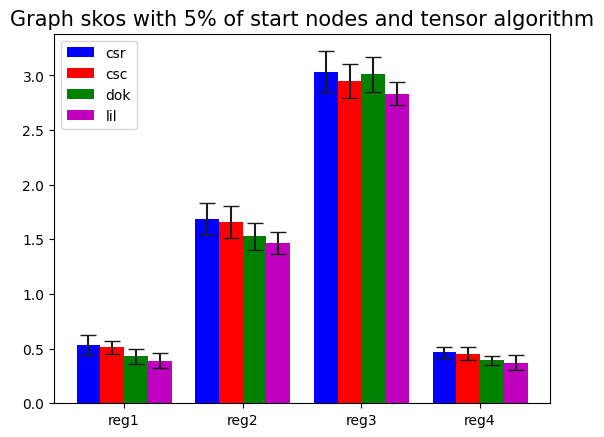

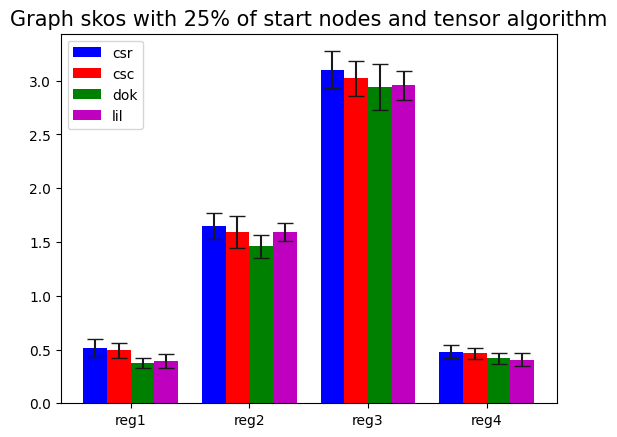

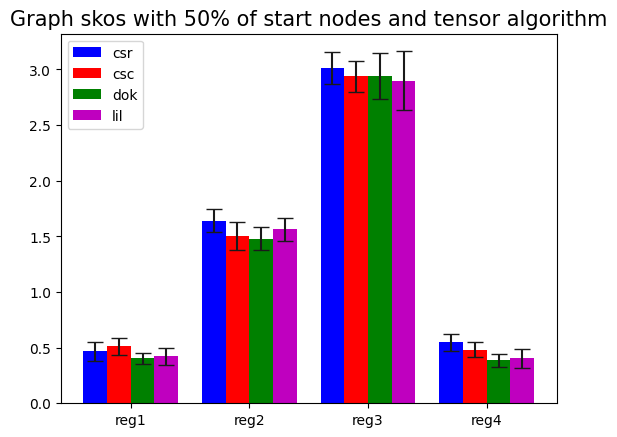

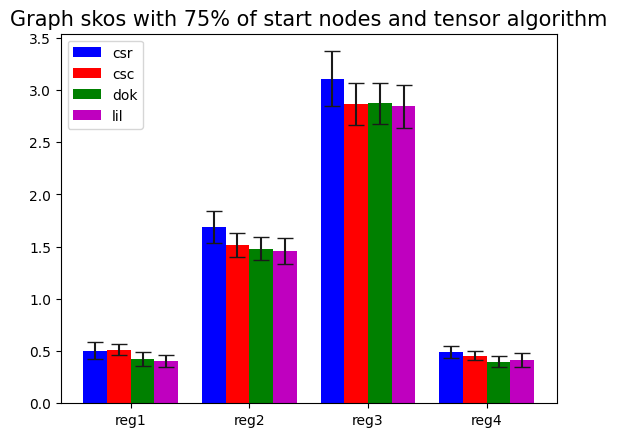

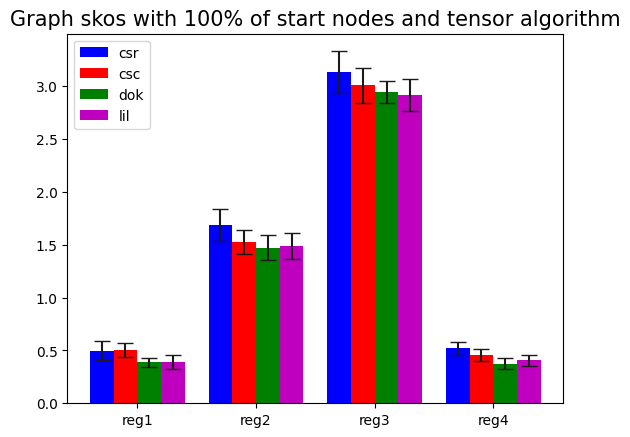

In [37]:
create_bar(
    graph_names[0],
    result_skos_tensor,
    matrix_representations.keys(),
    [list(algorithms.keys())[0]],
)

В задаче по достижимости между всеми парами вершин(tensor) dok и lil отрабатывает немного быстрее чем csr и csc, при этом. Наибольшую стабильность показало использование dok матриц. Так что определяем его, как наиболее подходящий вид представления.

#### Графики для графа wc, для задачи по достижимости между всеми парами вершин.

In [24]:
measures_skos_bfs = performance_test(
    [graph_names[0]],
    matrix_representations.keys(),
    [list(algorithms.keys())[1]],
    start_nodes_percent,
)
result_skos_bfs = get_result_table(measures_skos_bfs)
result_skos_bfs

C:\Users\kadoc\Documents\formal-lang-course\.venv\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\kadoc\Documents\formal-lang-course\.venv\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


,Graph,Matrix type,Algorithm,Regex,"Start set, %","Mean Time, s","Std Dev, s","Confidence interval, s"
0,skos,csr,bfs,({l1} | {l2})* {l3},5,0.069449,0.009830,"(0.064849, 0.07405)"
1,skos,csr,bfs,({l1} | {l2})* {l3},25,0.141187,0.002853,"(0.139852, 0.142523)"
2,skos,csr,bfs,({l1} | {l2})* {l3},50,0.237479,0.003983,"(0.235615, 0.239343)"
3,skos,csr,bfs,({l1} | {l2})* {l3},75,0.334675,0.005306,"(0.332192, 0.337159)"
4,skos,csr,bfs,({l1} | {l2})* {l3},100,0.433607,0.004804,"(0.431359, 0.435856)"
...,...,...,...,...,...,...,...,...
75,skos,lil,bfs,({l1} | {l2}) ({l3} | {l4})*,5,0.036190,0.017825,"(0.027848, 0.044532)"
76,skos,lil,bfs,({l1} | {l2}) ({l3} | {l4})*,25,0.152349,0.018522,"(0.14368, 0.161017)"
77,skos,lil,bfs,({l1} | {l2}) ({l3} | {l4})*,50,0.285956,0.018056,"(0.277506, 0.294407)"
78,skos,lil,bfs,({l1} | {l2}) ({l3} | {l4})*,75,0.445342,0.027749,"(0.432355, 0.458329)"


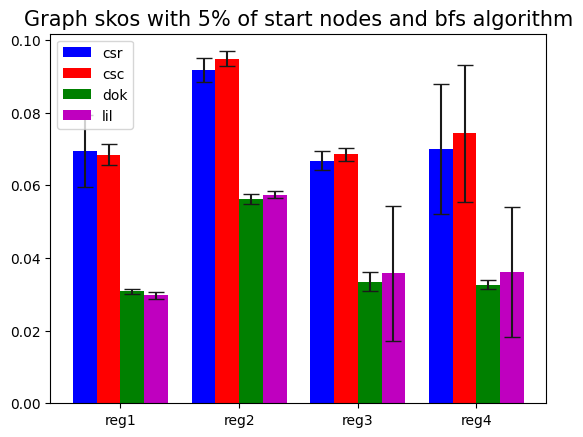

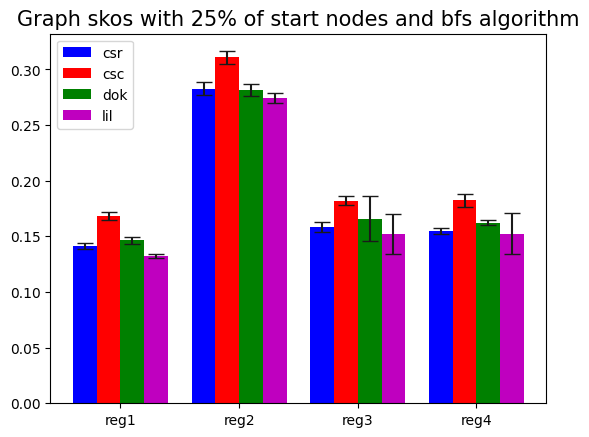

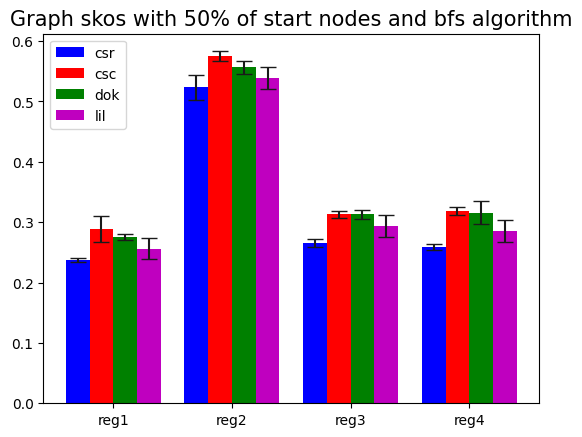

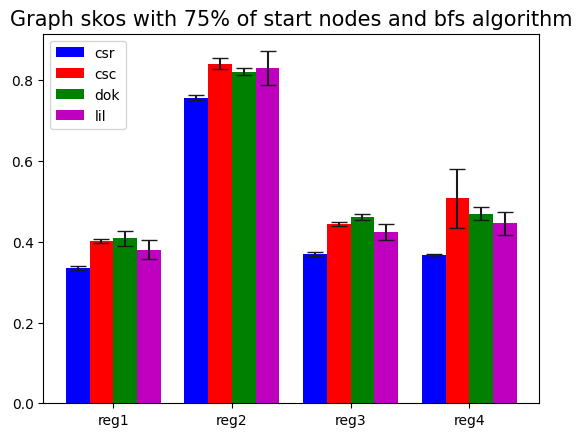

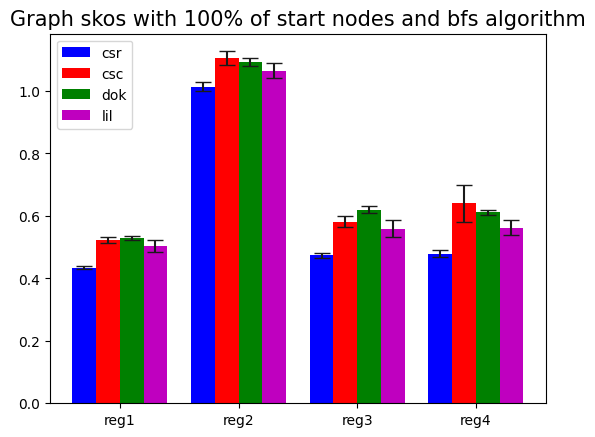

In [26]:
create_bar(
    graph_names[0],
    result_skos_bfs,
    matrix_representations.keys(),
    [list(algorithms.keys())[1]],
)

В задаче по достижимости для каждой из заданного множества стартовых вершин(bfs) на малом числе вершин dok и lil отрабатывают быстрее, при этом при увеличении числа вершин(с чуть больше 25%), csr показывает результат чуть лучше, чем dok и lil.

#### Сравнение двух алгоритмов относительно кол-ва вершин

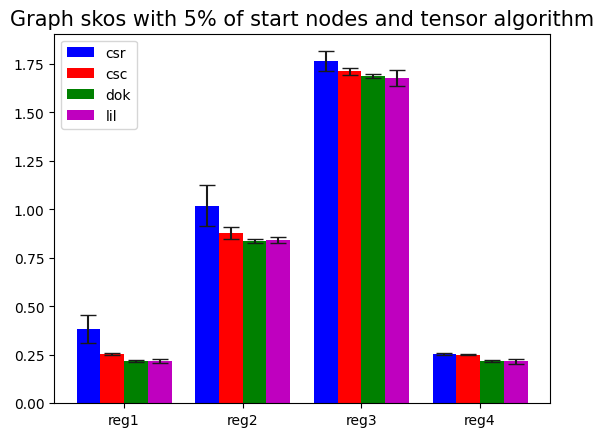

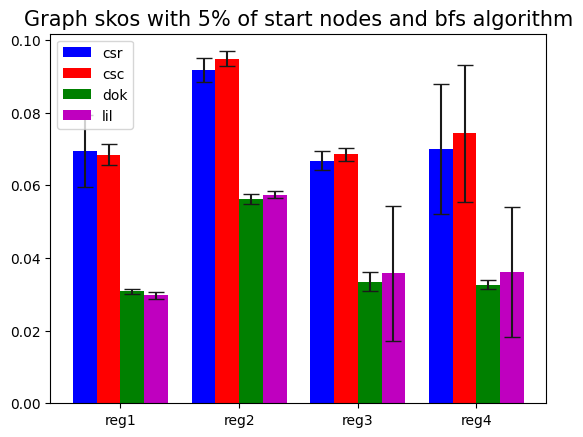

In [27]:
create_bar(
    graph_names[0],
    result_skos_tensor,
    matrix_representations.keys(),
    [list(algorithms.keys())[0]],
    [5],
)
create_bar(
    graph_names[0],
    result_skos_bfs,
    matrix_representations.keys(),
    [list(algorithms.keys())[1]],
    [5],
)

На 5% стартовых вершин bfs работает быстрее.

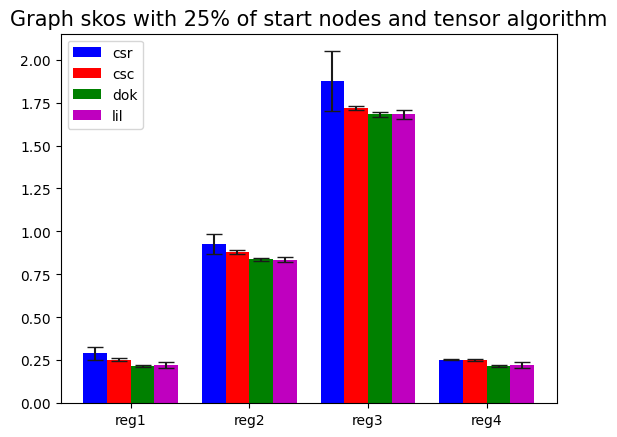

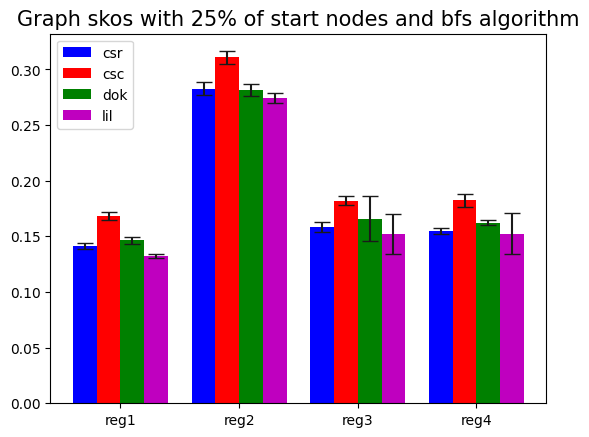

In [28]:
create_bar(
    graph_names[0],
    result_skos_tensor,
    matrix_representations.keys(),
    [list(algorithms.keys())[0]],
    [25],
)
create_bar(
    graph_names[0],
    result_skos_bfs,
    matrix_representations.keys(),
    [list(algorithms.keys())[1]],
    [25],
)

На 25% стартовых вершин bfs работает быстрее.

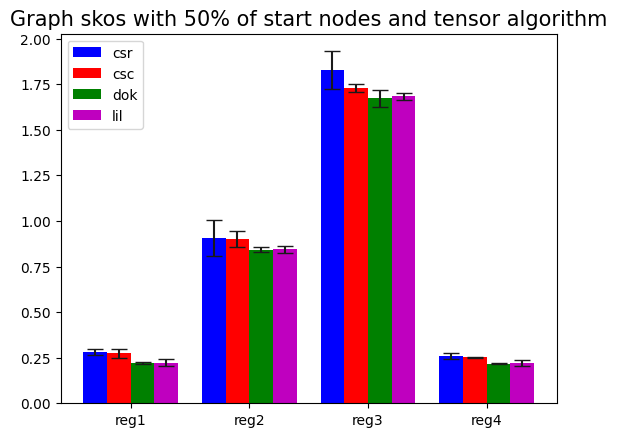

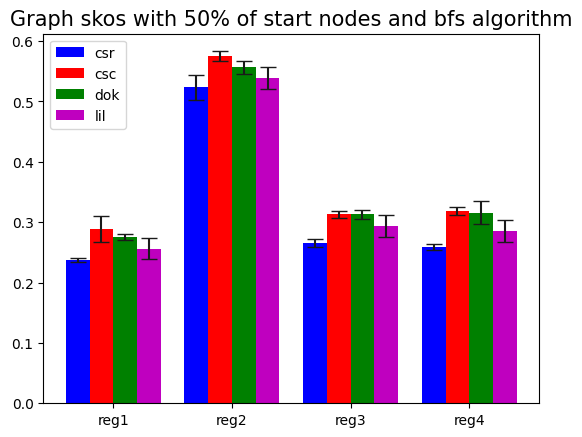

In [29]:
create_bar(
    graph_names[0],
    result_skos_tensor,
    matrix_representations.keys(),
    [list(algorithms.keys())[0]],
    [50],
)
create_bar(
    graph_names[0],
    result_skos_bfs,
    matrix_representations.keys(),
    [list(algorithms.keys())[1]],
    [50],
)

На 50% стартовых вершин bfs работает в сравнительной скорости с tensor на некоторых запросах. Но работает либо быстрее, либо так же, так что все еще остается в приоритете.

Если выбирать наиболее лучшее представление для tensor(doc) и bsf(csr), то bsf так же работает либо так же, либо лучше


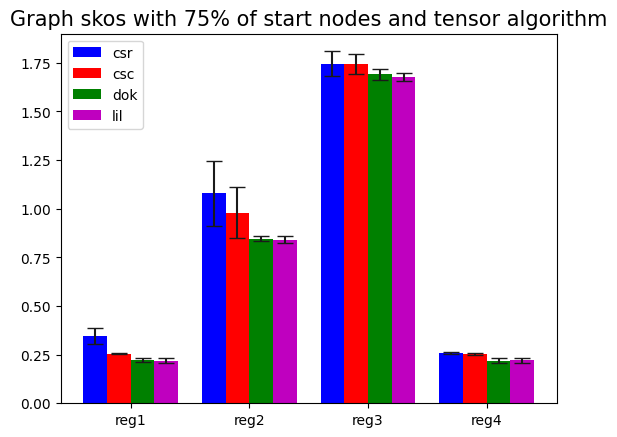

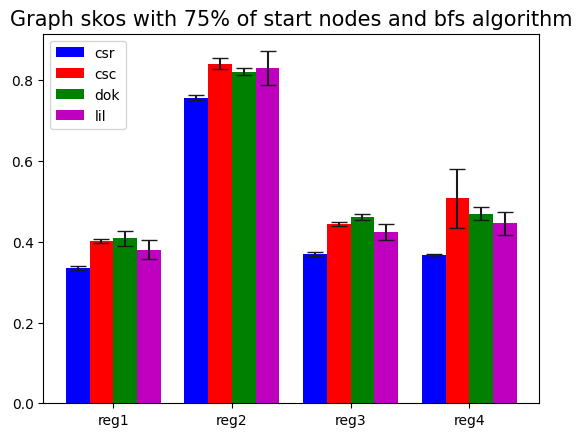

In [30]:
create_bar(
    graph_names[0],
    result_skos_tensor,
    matrix_representations.keys(),
    [list(algorithms.keys())[0]],
    [75],
)
create_bar(
    graph_names[0],
    result_skos_bfs,
    matrix_representations.keys(),
    [list(algorithms.keys())[1]],
    [75],
)

На 75% стартовых вершин tensor работает быстрее чем bsf на некоторых запросах.

Если выбирать наиболее лучшее представление для tensor(doc) и bsf(csr), то tensor работает быстрее за исключением третьего запроса.

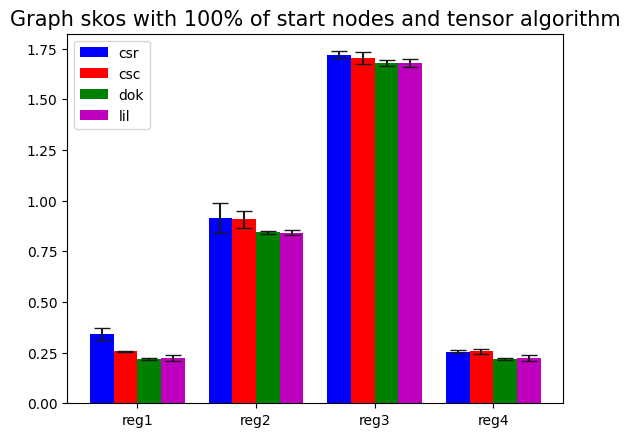

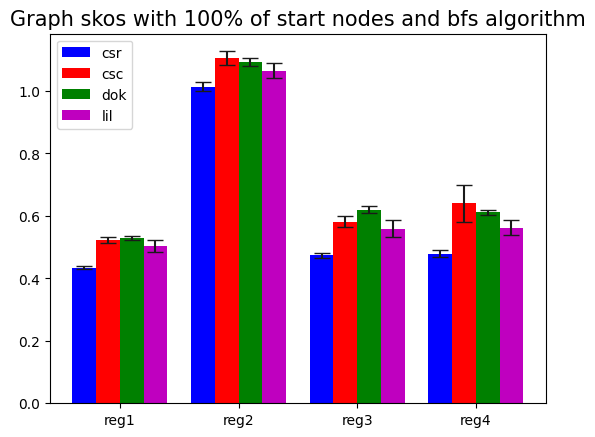

In [31]:
create_bar(
    graph_names[0],
    result_skos_tensor,
    matrix_representations.keys(),
    [list(algorithms.keys())[0]],
    [100],
)
create_bar(
    graph_names[0],
    result_skos_bfs,
    matrix_representations.keys(),
    [list(algorithms.keys())[1]],
    [100],
)

На 100% стартовых вершин tensor работает быстрее чем bsf за исключением третьего неудобного запроса(reg3).

Если выбирать наиболее лучшее представление для tensor(doc) и bsf(csr), то tensor работает быстрее за исключением третьего запроса.

### Результат

1. Для tensor_base_rpq алгоритма лучше всего подходит представление dok.
2. Для ms_bfs_based_rpq алгоритма на небольшом количестве стартовых вершин dok матрица и lil матрица показывают себя лучше всего. При увеличении количества стартовых вершин(начиная с чуть больше 25%) становится лучше csr
3. При размере стартового множества вершин больше 75% выгоднее решать задачу для всего множества вершин и из них выбирать нужные (tensor_base_rpq алгоритм). Для множества меньше 25% выгоднее ms_bfs_based_rpq алгоритм.